# Batch Inference vs Real-Time Inference

Not every prediction needs to happen in under 100 ms. Some jobs — scoring millions of users overnight, pre-computing recommendations — are better run as scheduled batch jobs. Choosing the wrong mode wastes money or degrades user experience.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 07 "07. Large Dataset Handling" — chunked, out-of-core processing of data too large for one pass is exactly the shape of a batch scoring job; the contrast drawn here is a service that must answer one row at a time in milliseconds.


## 📰 vLLM: 2–4× more throughput at the same latency, by batching differently

The single most influential serving paper of the last few years is Kwon et al., *Efficient Memory Management for Large Language Model Serving with PagedAttention* (SOSP 2023, arXiv 2309.06180) — the work behind vLLM. Its headline result: **2–4× the throughput of the previous state of the art at the same level of latency**, versus systems like FasterTransformer and Orca. It achieved that without a better model and without faster hardware. It changed *how requests are grouped*: instead of allocating a fixed block of key-value cache per request and running requests in lockstep, it pages the cache like an operating system pages memory, which lets many requests share a batch continuously as they arrive and finish.

That is this notebook's subject in its most extreme form. **Latency and throughput are not two names for speed — they are opposing objectives**, and the only way to get both is to control how work is grouped. You are about to measure the same trade on a scikit-learn model: the identical model, the identical predictions, and a **~900× difference in items per second** depending only on whether rows arrive one at a time over HTTP or 1,000 at a time in one call.

**What goes wrong without this lesson.** Pick real-time for a nightly job over 10 million users and you burn money and hours on HTTP overhead you never needed. Pick batch for a fraud check at checkout and the transaction times out. Both mistakes are architecture decisions made by default rather than by measurement — and both are expensive to reverse once clients depend on the interface.

## Learning Objectives

By the end of this notebook you will be able to:
1. Explain the difference between real-time and batch inference in terms of latency and throughput
2. Measure p50/p95 latency for a real-time serving endpoint
3. Run batch inference with chunking and measure items-per-second throughput
4. Choose the right mode for a given scenario using the decision guide

## 1. The Two Modes

**Real-time inference** (online serving):
- One request arrives → predict immediately → return response
- Latency target: < 100 ms (or < 20 ms for high-frequency use cases)
- Examples: fraud detection at checkout, search ranking, content recommendation at page load

**Batch inference** (offline scoring):
- Load all data → predict on thousands/millions at once → save results
- Throughput target: maximize items/second; latency is irrelevant
- Examples: nightly email recommendation generation, weekly churn scores for CRM

## 2. Setup — Train a Model

In [1]:
# WHAT: train the shared iris model both serving modes below will use.
# WHY: to compare batch vs real-time fairly, the MODEL must be identical —
# only the way requests reach it will differ.
import numpy as np
import pandas as pd
import time
import joblib
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Test accuracy: {acc:.2%}")

# Save for the serving endpoint
joblib.dump(clf, "/tmp/iris_batch_rt.joblib")
print("Model saved")

Test accuracy: 100.00%
Model saved


## Part 1 — Real-Time Inference

### Building the FastAPI Endpoint

In [2]:
%%writefile /tmp/realtime_app.py
# WHAT: write a minimal FastAPI app — the REAL-TIME side of the comparison.
# WHY: one request in, one prediction out, immediately; this is the mode you pay
# for with per-request overhead but win instant answers.
import joblib
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

app = FastAPI(title="Real-Time Iris Classifier")

model = joblib.load("/tmp/iris_batch_rt.joblib")
CLASSES = ["setosa", "versicolor", "virginica"]

class IrisFeatures(BaseModel):
    sepal_length: float
    sepal_width: float
    petal_length: float
    petal_width: float

@app.post("/predict")
async def predict(features: IrisFeatures):
    X = np.array([[features.sepal_length, features.sepal_width,
                   features.petal_length, features.petal_width]])
    class_id = int(model.predict(X)[0])
    return {"prediction": CLASSES[class_id], "class_id": class_id}

Overwriting /tmp/realtime_app.py


### Measuring p50 and p95 Latency

p50 (median) = half of requests are faster than this.
p95 = 95% of requests are faster than this. The p95 is what your worst-case users experience.

In [3]:
# WHAT: benchmark 500 single-prediction requests through the real-time API.
# WHY: real-time serving is judged by per-request latency percentiles — these
# numbers are the baseline the batch job below will be compared against.
import sys, importlib
sys.path.insert(0, "/tmp")
import realtime_app as rmod
importlib.reload(rmod)
from fastapi.testclient import TestClient

client = TestClient(rmod.app)

# Warm up (first call includes import overhead)
payload = {"sepal_length": 5.1, "sepal_width": 3.5, "petal_length": 1.4, "petal_width": 0.2}
_ = client.post("/predict", json=payload)

# Measure 500 single-prediction requests
N = 500
latencies_ms = []
for _ in range(N):
    t0 = time.perf_counter()
    client.post("/predict", json=payload)
    latencies_ms.append((time.perf_counter() - t0) * 1000)

# Sorting lets us read percentiles straight from the ordered list.
latencies_ms.sort()
p50 = latencies_ms[int(N * 0.50)]
p95 = latencies_ms[int(N * 0.95)]
p99 = latencies_ms[int(N * 0.99)]

print(f"Real-time inference latency ({N} requests, 1 sample each):")
print(f"  p50 (median): {p50:.2f} ms")
print(f"  p95:          {p95:.2f} ms")
print(f"  p99:          {p99:.2f} ms")
print(f"  max:          {max(latencies_ms):.2f} ms")
print(f"\nReal-time throughput: ~{1000/p50:.0f} requests/second at p50")

/Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


Real-time inference latency (500 requests, 1 sample each):
  p50 (median): 3.23 ms
  p95:          4.04 ms
  p99:          4.50 ms
  max:          6.67 ms

Real-time throughput: ~310 requests/second at p50


### When Real-Time Is Required

- **Fraud detection at checkout** — must score in < 200 ms or transaction times out
- **Search ranking** — results must appear before the user notices latency (< 50 ms)
- **Content recommendation at page load** — recommendation must return before the browser renders
- **Autonomous vehicle decisions** — must complete in < 10 ms at 100 Hz

## Part 2 — Batch Inference

### Generating a Large Dataset

In [4]:
# WHAT: generate a 1000-row CSV of unlabeled samples — the BATCH side's input.
# WHY: batch scoring starts from data at rest (a file, a table), not from live
# requests; ranges match real iris measurements so predictions are meaningful.
# Simulate 1000 rows of unlabeled user data that needs scoring
rng = np.random.default_rng(42)
N_BATCH = 1000

df = pd.DataFrame(
    rng.uniform(low=[4.3, 2.0, 1.0, 0.1], high=[7.9, 4.4, 6.9, 2.5], size=(N_BATCH, 4)),
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

# Batch jobs read from durable storage — writing the CSV simulates that handoff.
INPUT_CSV = "/tmp/batch_input.csv"
df.to_csv(INPUT_CSV, index=False)
print(f"Generated {len(df)} rows → {INPUT_CSV}")
print(df.head(3))

Generated 1000 rows → /tmp/batch_input.csv
   sepal_length  sepal_width  petal_length  petal_width
0      7.086242     3.053308      6.065728     1.773683
1      4.639038     4.341494      5.490724     1.986554
2      4.761209     3.080926      3.187708     2.324236


### Run Batch Inference — Full DataFrame at Once

In [5]:
# Load the CSV
batch_df = pd.read_csv(INPUT_CSV)
X_batch = batch_df.values

# Run all 1000 predictions in a single call
t0 = time.perf_counter()
predictions = clf.predict(X_batch)
probabilities = clf.predict_proba(X_batch)
elapsed = time.perf_counter() - t0

CLASSES = ["setosa", "versicolor", "virginica"]
batch_df["prediction"] = [CLASSES[p] for p in predictions]
batch_df["confidence"] = probabilities.max(axis=1).round(3)

OUTPUT_CSV = "/tmp/batch_output.csv"
batch_df.to_csv(OUTPUT_CSV, index=False)

throughput = len(X_batch) / elapsed
print(f"Batch inference: {len(X_batch)} rows in {elapsed*1000:.1f} ms")
print(f"Throughput: {throughput:,.0f} items/second")
print(f"Output saved: {OUTPUT_CSV}")
print(batch_df[["sepal_length", "prediction", "confidence"]].head())

Batch inference: 1000 rows in 8.2 ms
Throughput: 122,228 items/second
Output saved: /tmp/batch_output.csv
   sepal_length prediction  confidence
0      7.086242  virginica        1.00
1      4.639038  virginica        0.86
2      4.761209  virginica        0.64
3      6.617914     setosa        0.53
4      6.296505  virginica        0.69


### Chunked Batch Processing

For very large datasets (millions of rows), you can't load everything into memory. Process in chunks of 256 rows at a time.

In [6]:
# WHAT: score the same CSV in chunks of 256 rows, appending results as we go.
# WHY: chunking bounds memory — this same loop works when the input is 100 GB,
# which is exactly when batch pipelines are chosen over APIs.
CHUNK_SIZE = 256
OUTPUT_CHUNKED = "/tmp/batch_output_chunked.csv"

first_chunk = True
total_rows = 0
t0 = time.perf_counter()

# Each iteration: read a slice, predict it, append it to the output file.
for chunk in pd.read_csv(INPUT_CSV, chunksize=CHUNK_SIZE):
    X_chunk = chunk.values
    preds = clf.predict(X_chunk)
    probs = clf.predict_proba(X_chunk)

    chunk["prediction"] = [CLASSES[p] for p in preds]
    chunk["confidence"] = probs.max(axis=1).round(3)

    # Append to output CSV (header only on first chunk)
    chunk.to_csv(OUTPUT_CHUNKED, mode="a", header=first_chunk, index=False)
    first_chunk = False
    total_rows += len(chunk)
    print(f"  Processed chunk: {len(chunk)} rows  (total: {total_rows})")

# Compare total wall time with the real-time p50 x 1000 to see the throughput win.
elapsed_chunked = time.perf_counter() - t0
print(f"\nChunked batch: {total_rows} rows in {elapsed_chunked*1000:.1f} ms")
print(f"Output: {OUTPUT_CHUNKED}")

  Processed chunk: 256 rows  (total: 256)
  Processed chunk: 256 rows  (total: 512)
  Processed chunk: 256 rows  (total: 768)
  Processed chunk: 232 rows  (total: 1000)

Chunked batch: 1000 rows in 31.0 ms
Output: /tmp/batch_output_chunked.csv


## Part 3 — Throughput Comparison

In [7]:
# Simulate real-time: send 1000 requests one by one
N_RT = 1000
rt_latencies = []

for row in X_batch:
    pl = {"sepal_length": float(row[0]), "sepal_width": float(row[1]),
          "petal_length": float(row[2]), "petal_width": float(row[3])}
    t0 = time.perf_counter()
    client.post("/predict", json=pl)
    rt_latencies.append(time.perf_counter() - t0)

rt_total = sum(rt_latencies)
rt_throughput = N_RT / rt_total

# Batch throughput
t0 = time.perf_counter()
clf.predict(X_batch)
batch_elapsed = time.perf_counter() - t0
batch_throughput = N_RT / batch_elapsed

print(f"{'Mode':<20} {'Items/sec':<15} {'Total time (1000 items)'}")
print("-" * 55)
print(f"{'Real-time (API)':<20} {rt_throughput:<15,.0f} {rt_total*1000:.1f} ms")
print(f"{'Batch (direct)':<20} {batch_throughput:<15,.0f} {batch_elapsed*1000:.1f} ms")
print(f"\nBatch is {batch_throughput/rt_throughput:.1f}x faster per item than simulated real-time API")
print("(API overhead: serialization, routing, HTTP parsing)")

Mode                 Items/sec       Total time (1000 items)
-------------------------------------------------------
Real-time (API)      285             3510.2 ms
Batch (direct)       256,438         3.9 ms

Batch is 900.2x faster per item than simulated real-time API
(API overhead: serialization, routing, HTTP parsing)


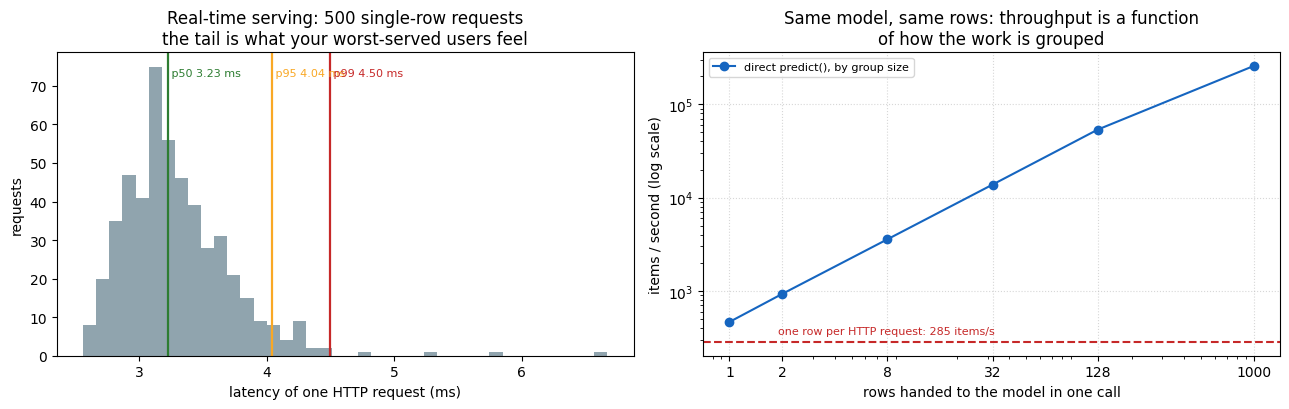

rows per call      items/second   vs one-row API
1                           467   x2
2                           930   x3
8                         3,578   x13
32                       13,804   x48
128                      53,647   x188
1000                    257,891   x905

Latency distribution: p50 3.23 ms, p95 4.04 ms, p99 4.50 ms, max 6.67 ms - the p99 is 2.1x the median at worst.


In [8]:
# WHAT: draw the two measurements this notebook lives on - the shape of the
# real-time latency distribution, and how throughput changes as the SAME model is
# handed the same 1000 rows in groups of different sizes.
# WHY: p50/p95/p99 are three points on a distribution you have not seen yet, and
# "batch is 678x faster per item" is one point on a curve. Both deserve their picture.
import matplotlib.pyplot as plt

# Batch-size sweep: identical model, identical rows, only the grouping changes.
GROUPS = [1, 2, 8, 32, 128, 1000]
REPEATS = 30
group_throughput = []
for g in GROUPS:
    rows = X_batch[:g]
    clf.predict(rows)                       # warm-up
    t0 = time.perf_counter()
    for _ in range(REPEATS):
        clf.predict(rows)
    dt = (time.perf_counter() - t0) / REPEATS
    group_throughput.append(g / dt)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(latencies_ms, bins=40, color="#90a4ae")
for value, label, colour in [(p50, "p50", "#2e7d32"),
                             (p95, "p95", "#f9a825"),
                             (p99, "p99", "#c62828")]:
    ax.axvline(value, color=colour, lw=1.6)
    ax.text(value, ax.get_ylim()[1] * 0.92, f" {label} {value:.2f} ms",
            color=colour, fontsize=8)
ax.set_xlabel("latency of one HTTP request (ms)")
ax.set_ylabel("requests")
ax.set_title(f"Real-time serving: {len(latencies_ms)} single-row requests\n"
             f"the tail is what your worst-served users feel")

ax = axes[1]
ax.plot(GROUPS, group_throughput, "o-", color="#1565c0", label="direct predict(), by group size")
ax.axhline(rt_throughput, ls="--", lw=1.5, color="#c62828")
ax.text(1.9, rt_throughput * 1.22, f"one row per HTTP request: {rt_throughput:,.0f} items/s",
        fontsize=8, color="#c62828")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(GROUPS)
ax.set_xticklabels(GROUPS)
ax.set_xlabel("rows handed to the model in one call")
ax.set_ylabel("items / second (log scale)")
ax.set_title("Same model, same rows: throughput is a function\nof how the work is grouped")
# upper left: the lower-right corner is where the red reference line lives, and a
# legend box parked on top of it hides the very line it is explaining.
ax.legend(fontsize=8, loc="upper left")
ax.grid(ls=":", alpha=0.5)

plt.tight_layout()
plt.show()

# The right-hand curve as a step table.
print(f"{'rows per call':<16} {'items/second':>14}   vs one-row API")
for g, tp in zip(GROUPS, group_throughput):
    print(f"{g:<16} {tp:>14,.0f}   x{tp / rt_throughput:,.0f}")
print(f"\nLatency distribution: p50 {p50:.2f} ms, p95 {p95:.2f} ms, p99 {p99:.2f} ms, "
      f"max {max(latencies_ms):.2f} ms - the p99 is {max(latencies_ms) / p50:.1f}x "
      f"the median at worst.")


**Reading the figure.** *Left:* the 500 measured request latencies, not their summary. Most
requests land in a narrow spike, and p50/p95/p99 mark how far right you have to walk before
you have covered 50%, 95% and 99% of them. The distance between the green line and the red
one is the entire reason serving is judged on percentiles: quoting the median describes a
request that half your users never get.

*Right, log-log:* the same model scoring the same rows, with only the **grouping** changed. The
red line is the one-row-per-HTTP-request mode measured earlier in this notebook. Notice where the curve starts: even at **one row per call**, going straight to
`predict()` already beats the API line, and that first gap is pure HTTP — serialisation,
routing, parsing — with no batching involved at all. Each step up the blue curve is the fixed per-call cost — Python dispatch, argument checking, HTTP
parsing — being shared across more rows, and it keeps paying up to the full 1,000-row call.
This is the batch-versus-API gap from section 3 shown as what it really is: **not a property of batch inference,
but a curve you move along by choosing how many rows arrive together.** Nothing about the
model changed anywhere on this plot.

## 💬 Discuss

The comparison is stark: **285 items/second** through the API versus **257,891 items/second** when the same 1,000 rows go in one call — an ~900× gap on the same model and the same rows, produced entirely by per-request overhead (serialization, routing, HTTP parsing). Now argue what to do about it.

1. If batching is ~900× more efficient per item, why not batch everything? Describe a request where waiting 200 ms to collect a batch is unacceptable, and one where waiting 2 hours is fine. What actually distinguishes them — is it the latency number, or something about who is waiting?
2. Between those extremes sits **micro-batching**: hold requests for 20–50 ms, score them together. That is what vLLM does continuously, and what TorchServe's `batch_delay` does crudely. Who pays for it, and who benefits? Would you enable it on the fraud endpoint from section 4?
3. Our chunked run took **31.0 ms** for 1,000 rows against **8.2 ms** for the single-call version — chunking made it slower here. When does that reverse, and what would you have to know about the dataset and the machine before choosing a chunk size?

## Part 4 — Decision Guide

| Scenario | Latency need | Volume | Choose |
|---|---|---|---|
| Fraud detection at checkout | < 200 ms | 1 at a time | Real-time |
| Search result ranking | < 50 ms | 1 query at a time | Real-time |
| Email recommendations (nightly) | None | 10M users | Batch |
| Churn scores for CRM (weekly) | None | 1M customers | Batch |
| Inventory reorder suggestions (daily) | None | 100K items | Batch |
| Autocomplete as user types | < 20 ms | 1 at a time | Real-time |

**Recovery from batch failures:** If a batch job fails at row 500K out of 1M, save a checkpoint. On restart, skip to the checkpoint row. Never re-process rows you already scored — output files should be append-only.

## 5. Summary

In this notebook you:
- Built a FastAPI real-time endpoint and measured p50/p95/p99 latency across 500 requests
- Ran batch inference on 1000 rows in a single `clf.predict()` call and measured throughput
- Implemented chunked batch processing for datasets too large to fit in memory
- Compared items/second: batch is significantly faster per item because it avoids HTTP overhead

**The key trade-off:** real-time minimizes latency for individual requests; batch maximizes throughput for large volumes. They serve different use cases — most production systems need both.

## Self-Check (answer before scrolling up)

1. **Which mode would you use for generating email recommendations overnight for 10 million users?** Explain why real-time would be impractical here.
2. **Why is batch inference more efficient per sample than single-request serving?** Name at least two sources of overhead that batch avoids.
3. **What happens if a batch job fails at row 500K out of 1 million?** How would you design the job so you don't have to restart from row 1?

## ⚠️ Where this breaks

- **The ~900× is mostly HTTP, not modelling.** It is a measurement of per-request overhead on a tiny model, in-process, with `TestClient`. On a large model where the forward pass dominates, the gap narrows sharply. Quote the *shape* of this result (batch wins on throughput, loses on latency), never the number.
- **Chunking is not free, and this notebook shows it.** Chunked processing cost about 3.8× the wall time of the single call on 1,000 rows, because the per-chunk overhead was not yet amortised. Chunking is a **memory** technique for data that does not fit, not a speed technique. Choose the chunk size from your memory ceiling, then measure.
- **Batch jobs fail differently.** A real-time endpoint fails one request; a batch job fails at row 500,000 of a million and leaves half-written output. The checkpoint-and-append design in section 4 is the minimum, and it only works if your output is genuinely idempotent — re-scoring a row must produce the same result, which stops being true the moment the model version changes mid-run.
- **The assumption that must hold:** batch inputs are already assembled somewhere. Batch scoring is cheap because the features are sitting in a CSV or a warehouse table. If the features must be computed per row from a live feature store, the "cheap" batch job inherits all the per-row cost you thought you had avoided.
- **A third option this notebook does not cover.** Many production systems do neither: they **pre-compute** predictions in batch and serve them from a key-value store at request time. Latency becomes a cache lookup, throughput becomes a nightly job — at the cost of predictions that are up to 24 hours stale. If your inputs change slowly (churn scores, content recommendations), that is usually the cheapest correct answer.

**The same trade shows up in:** a database choosing row-at-a-time versus bulk load; a payment processor settling in batches overnight while authorising in milliseconds; a GPU training loop choosing batch size against memory.

## 📚 References

1. Crankshaw, D., Wang, X., Zhou, G., Franklin, M. J., Gonzalez, J. E., & Stoica, I. (2017). *Clipper: A Low-Latency Online Prediction Serving System*. NSDI. <https://arxiv.org/abs/1612.03079>
2. Olston, C., Fiedel, N., Gorovoy, K., et al. (2017). *TensorFlow-Serving: Flexible, High-Performance ML Serving*. NeurIPS Workshop on ML Systems. <https://arxiv.org/abs/1712.06139>
3. Kreuzberger, D., Kühl, N., & Hirschl, S. (2022). *Machine Learning Operations (MLOps): Overview, Definition, and Architecture*. IEEE Access. <https://arxiv.org/abs/2205.02302>
